In [1]:
import pandas as pd
import numpy as np
import ast
from pathlib import Path

cwd = Path.cwd()
CSV_PATH = cwd.parent.parent / "tests" / "epoch_grid_neural_net_tests_35_models.csv"

In [2]:
df = pd.read_csv(CSV_PATH, low_memory=False)
df.head(5)

,trial_num,epochs,split_seed,trial_seed,total_parameters,hidden_layer_sizes,dropout_size,has_batch_normalization,train_MSE,test_MSE,train_RMSE,test_RMSE,train_r2_score,test_r2_score,train_y,train_model_y,test_y,test_model_y
0,1,100,42,67,5877,"[4, 8, 16, 8]",0.2,False,0.006025,0.006329,0.077622,0.079555,0.9138,0.9167,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.24138274788856506, 0.33932557702064514, 0.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.6958584785461426, 0.08329388499259949, 0.28..."
1,2,200,42,68,5877,"[4, 8, 16, 8]",0.2,False,0.004543,0.004568,0.067402,0.067588,0.9350,0.9399,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.23799677193164825, 0.3046683073043823, 0.04...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7411972880363464, 0.04759548604488373, 0.24..."
2,3,500,42,69,5877,"[4, 8, 16, 8]",0.2,False,0.002701,0.002788,0.051969,0.052801,0.9614,0.9633,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.23734436929225922, 0.3107035756111145, 0.03...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.69977867603302, 0.09102480113506317, 0.2569..."
3,4,1000,42,70,5877,"[4, 8, 16, 8]",0.2,False,0.002593,0.002594,0.050926,0.050936,0.9629,0.9659,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.22084319591522217, 0.3238254189491272, 0.04...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.6871535181999207, 0.07448771595954895, 0.25..."
4,5,2000,42,71,5877,"[4, 8, 16, 8]",0.2,False,0.002167,0.002561,0.046547,0.050603,0.9690,0.9663,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.2192191183567047, 0.2971348762512207, 0.028...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.76317298412323, 0.04990461468696594, 0.2484..."


In [3]:
def string_to_float_array(s):
    return np.array(ast.literal_eval(s), dtype=float)

In [4]:
df["train_y"] = df["train_y"].apply(string_to_float_array)
df["train_model_y"] = df["train_model_y"].apply(string_to_float_array)
df["test_y"] = df["test_y"].apply(string_to_float_array)
df["test_model_y"] = df["test_model_y"].apply(string_to_float_array)

In [5]:
df["arch"] = tuple(df["hidden_layer_sizes"])

In [6]:
models_by_epochs = {}
for num_epochs in df['epochs'].unique():
    models_by_epochs[int(num_epochs)] = df[(df['epochs'] == num_epochs)]

In [7]:
for num_epochs in models_by_epochs:
    models_by_epochs[num_epochs] = (
        models_by_epochs[num_epochs]
        .sort_values(["total_parameters"], ascending=True)
        .reset_index(drop=True)
    )

In [8]:
first_epochs = 0
for num_epochs in models_by_epochs:
    first_epochs = num_epochs
    break
models_by_epochs[first_epochs]

,trial_num,epochs,split_seed,trial_seed,total_parameters,hidden_layer_sizes,dropout_size,has_batch_normalization,train_MSE,test_MSE,train_RMSE,test_RMSE,train_r2_score,test_r2_score,train_y,train_model_y,test_y,test_model_y,arch
0,1,100,42,67,5877,"[4, 8, 16, 8]",0.2,False,0.006025,0.006329,0.077622,0.079555,0.9138,0.9167,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.24138274788856506, 0.33932557702064514, 0.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.6958584785461426, 0.08329388499259949, 0.28...","[4, 8, 16, 8]"
1,8,100,42,134,6821,"[4, 8, 16, 32, 16]",0.2,False,0.005596,0.005851,0.074808,0.076491,0.9199,0.9230,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.2194821834564209, 0.2709811329841614, 0.028...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7217073440551758, 0.03656208515167236, 0.25...","[4, 8, 16, 32, 16]"
2,15,100,42,201,7877,"[4, 8, 16, 64, 16]",0.2,False,0.003154,0.003275,0.056162,0.057230,0.9549,0.9569,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.25328704714775085, 0.3171718418598175, 0.01...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7830308675765991, 0.0432891845703125, 0.280...","[4, 8, 16, 64, 16]"
3,22,100,42,268,9045,"[4, 8, 32, 64, 16]",0.2,False,0.009811,0.010181,0.099050,0.100900,0.8596,0.8661,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.2370772361755371, 0.27295196056365967, 0.04...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.6446147561073303, 0.05100608617067337, 0.21...","[4, 8, 32, 64, 16]"
4,29,100,42,335,9341,"[4, 16, 32, 64, 16]",0.2,False,0.003444,0.003469,0.058686,0.058899,0.9507,0.9544,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.23235177993774414, 0.311975359916687, 0.041...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.8681251406669617, 0.05937559902667999, 0.29...","[4, 16, 32, 64, 16]"


In [9]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

In [10]:
def plot_scatter_with_fit(ax, x, y):
    # Scatter
    ax.scatter(x, y, s=10, alpha=0.6)

    # Regression line (least squares)
    m, b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 200)
    ax.plot(xx, m*xx + b, color="red", linestyle="--", linewidth=2, label=f"fit: y={m:.2f}x+{b:.2f}")

    # y = x reference line
    ax.plot(xx, xx, color="black", linewidth=1, alpha=0.6, label="ideal: y=x")

    ax.legend()

In [11]:
def plot_related(df):
    fig, axes = plt.subplots(len(df), 2, figsize=(15, 4*len(df)))
    axes = np.atleast_2d(axes)
    
    for i, row in df.reset_index(drop=True).iterrows():
        x_tr = np.asarray(row["train_y"], dtype=float)
        y_tr = np.asarray(row["train_model_y"], dtype=float)
        x_te = np.asarray(row["test_y"], dtype=float)
        y_te = np.asarray(row["test_model_y"], dtype=float)
    
        plot_scatter_with_fit(axes[i, 0], x_tr, y_tr)
        axes[i, 0].set_title(f'TRAIN - {row['epochs']} Epochs - Parameters: {row["arch"]} = {row["total_parameters"]} (trial {row["trial_num"]})')
        axes[i, 0].set_xlabel(r"Train y ($\mu$m)")
        axes[i, 0].set_ylabel(r"Model Train y ($\mu$m)")
    
        plot_scatter_with_fit(axes[i, 1], x_te, y_te)
        axes[i, 1].set_title(f'TEST - {row['epochs']} Epochs - Parameters: {row["arch"]} = {row["total_parameters"]} (trial {row["trial_num"]})')
        axes[i, 1].set_xlabel(r"Test y ($\mu$m)")
        axes[i, 1].set_ylabel(r"Model Test y ($\mu$m)")
    
    plt.tight_layout()
    plt.show()

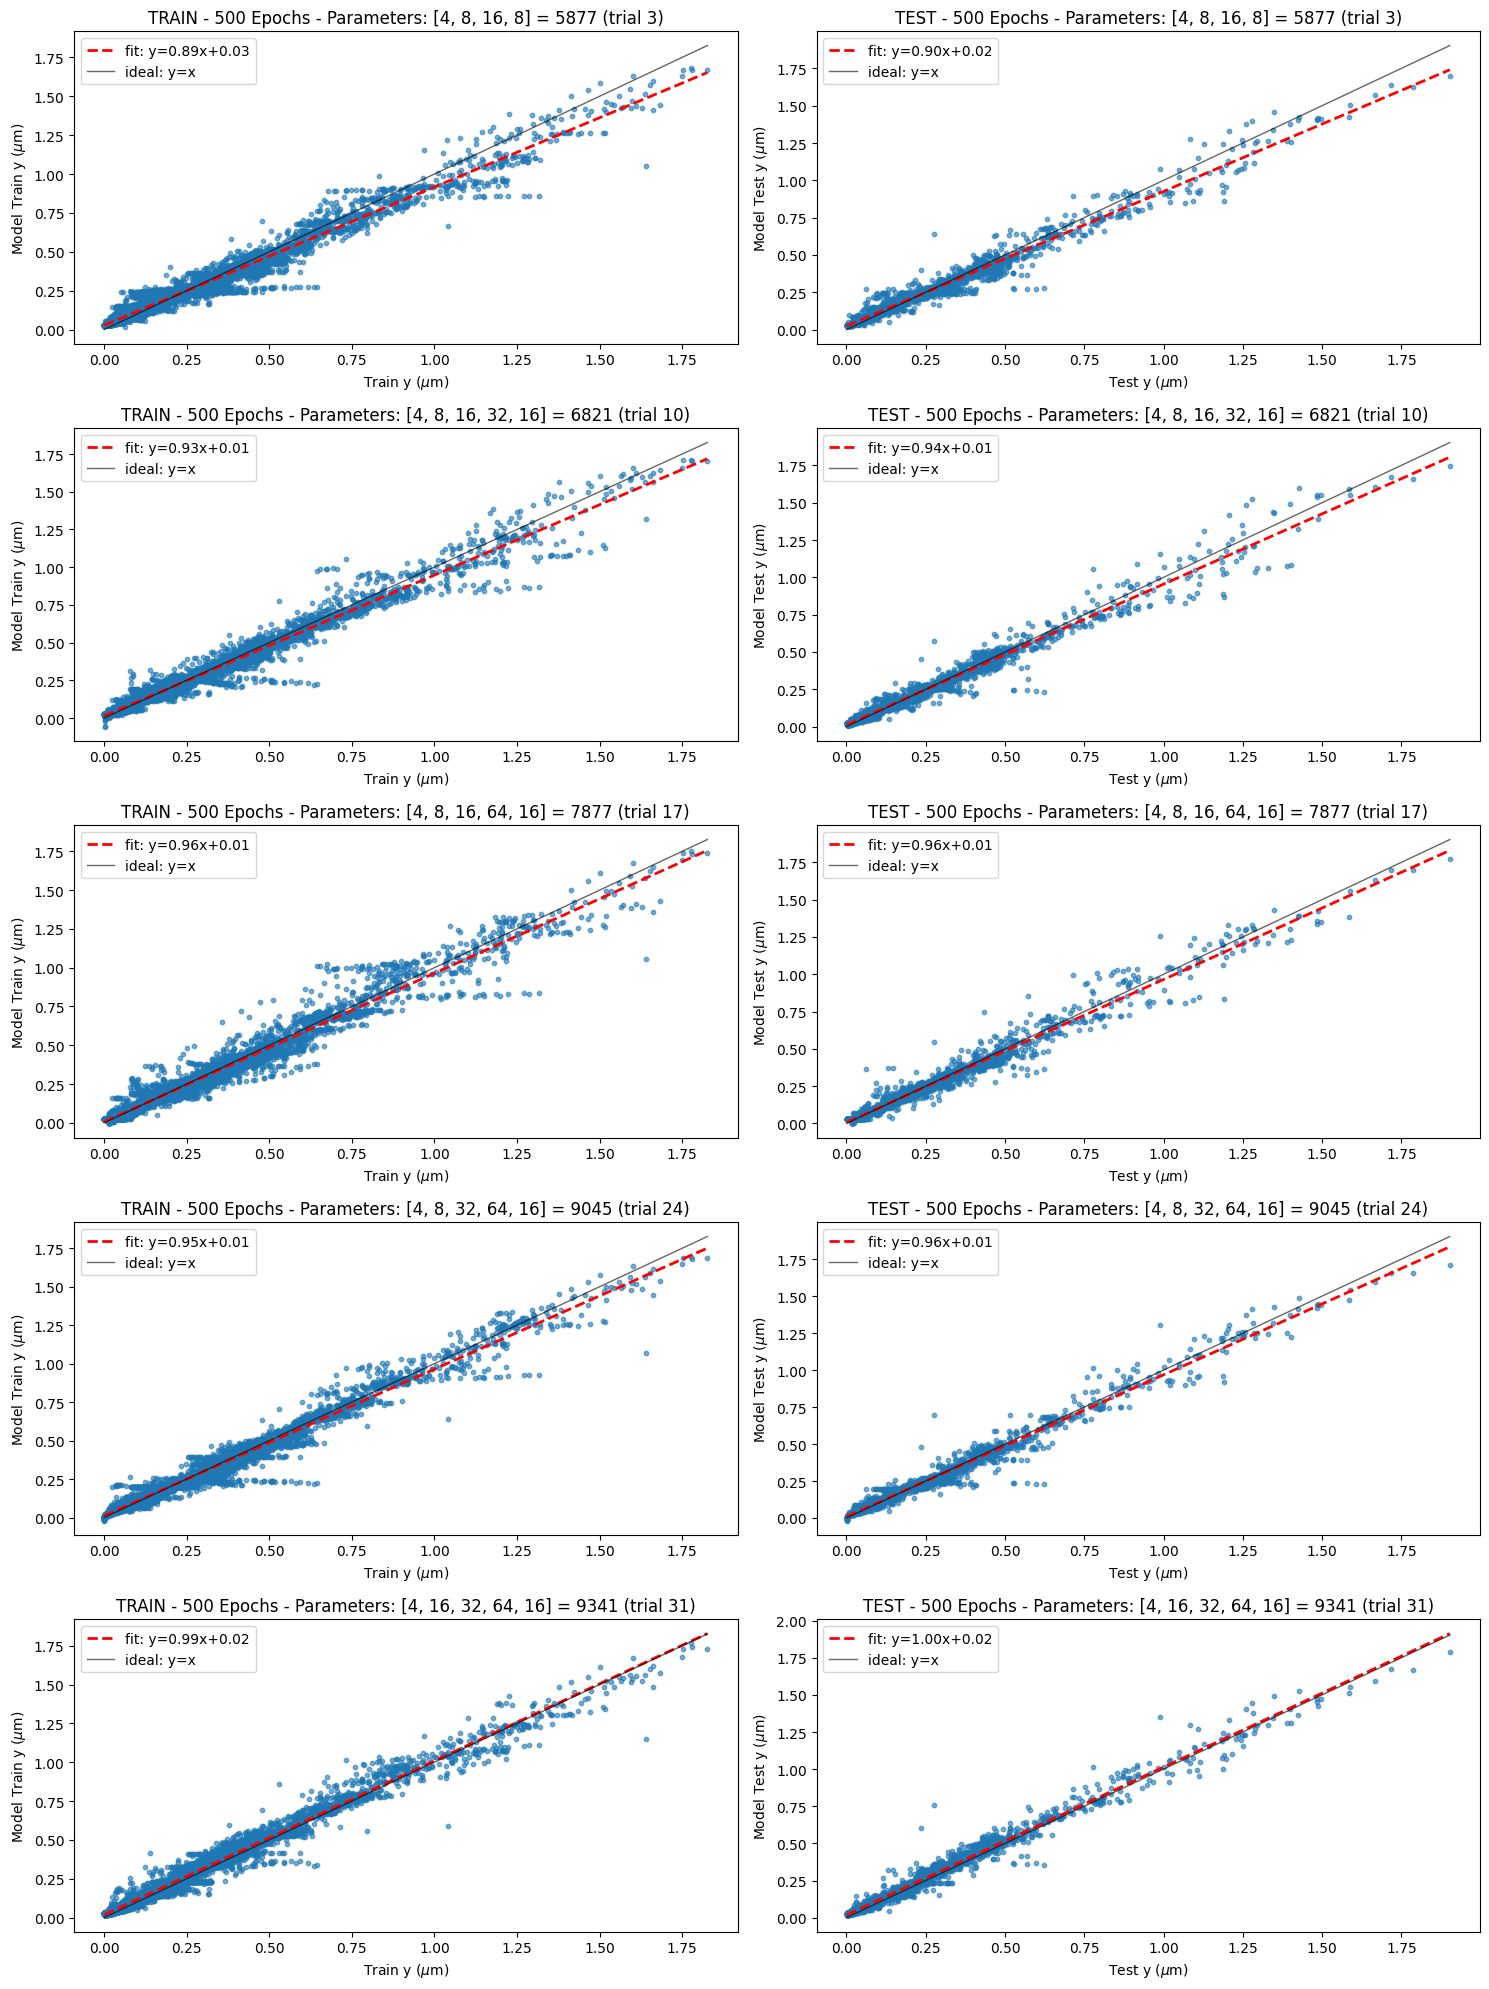

In [12]:
# epochs: 100, 200, 500, 1000, 2000, 3000, 5000
###
view_epocs = 500

plot_related(models_by_epochs[view_epocs])

In [13]:
# ------------------ checks & cleaning ------------------
required_cols = ["train_MSE", "test_MSE", "epochs", "arch", "total_parameters"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"df is missing required columns: {missing}")

plot_df = df[required_cols].copy()
for c in ["train_MSE", "test_MSE", "epochs", "total_parameters"]:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

plot_df["arch"] = plot_df["arch"].astype(str)
plot_df = plot_df.dropna(subset=required_cols)

In [14]:
# ------------------ order architectures by size ------------------
arch_order = (
    plot_df.groupby("arch")["total_parameters"]
    .mean()                 # constant per arch, but mean is safe
    .sort_values()          # least → most parameters
    .index
    .tolist()
)

plot_df["arch"] = pd.Categorical(
    plot_df["arch"], categories=arch_order, ordered=True
)

In [15]:
# ------------------ color mapping ------------------
n_arch = len(arch_order)
cmap = plt.get_cmap("tab20" if n_arch <= 20 else "gist_ncar")
denom = max(n_arch - 1, 1)

color_map = {
    arch: cmap(i / denom)
    for i, arch in enumerate(arch_order)
}

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="-",
        color=color_map[arch],
        markerfacecolor=color_map[arch],
        markeredgecolor="none",
        markersize=6,
        label=arch
    )
    for arch in arch_order
]

In [16]:
# ------------------ plotting function ------------------
def plot_mse(y_col: str, title: str, logx=False, logy=True):
    plt.figure(figsize=(10, 6))

    for arch in arch_order:
        sub = (
            plot_df[plot_df["arch"] == arch]
            .sort_values("epochs")
        )

        plt.plot(
            sub["epochs"],
            sub[y_col],
            marker="o",
            linestyle="-",
            linewidth=1.2,
            markersize=4,
            alpha=0.85,
            color=color_map[arch],
        )

    if logx:
        plt.xscale("log")
    if logy:
        plt.yscale("log")

    plt.xlabel("epochs" + (" (log)" if logx else ""))
    plt.ylabel(y_col + (" (log)" if logy else ""))
    plt.title(title)

    plt.legend(
        handles=legend_handles,
        title="hidden layers (increasing parameter order)",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

    plt.tight_layout()
    plt.show()

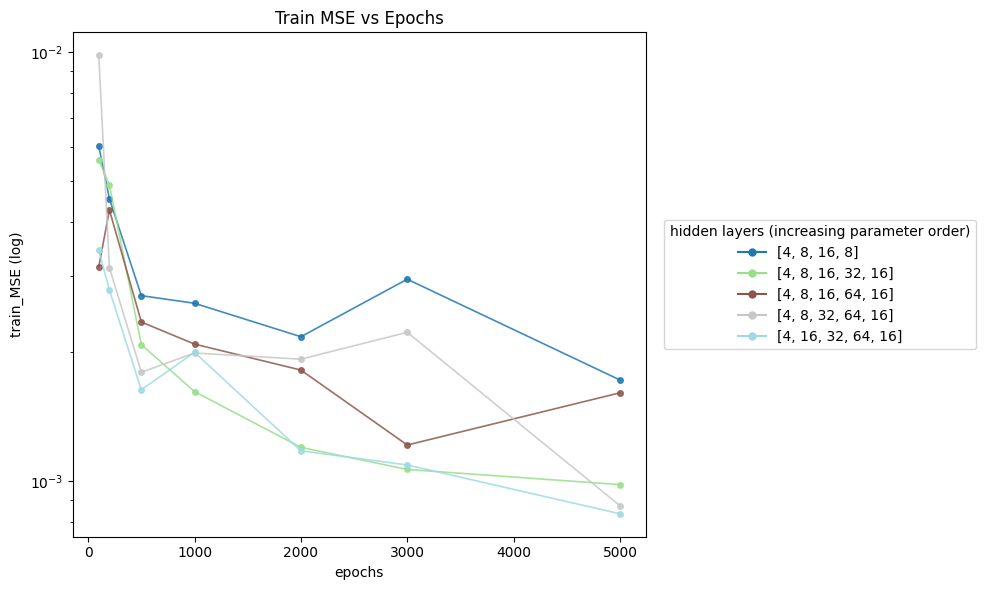

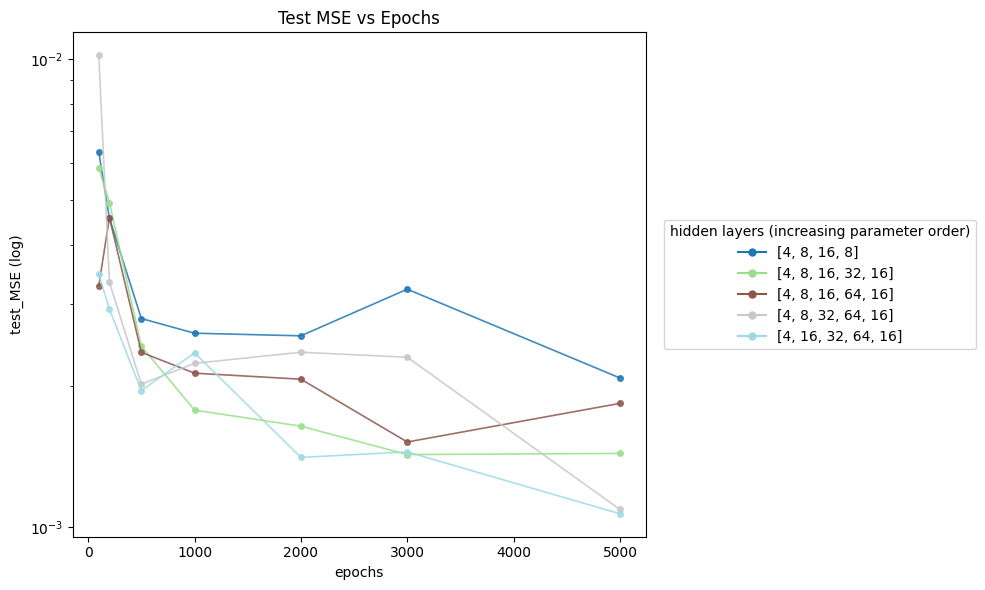

In [17]:
# ------------------ plots ------------------
plot_mse(
    "train_MSE",
    "Train MSE vs Epochs"
)

plot_mse(
    "test_MSE",
    "Test MSE vs Epochs"
)

# 5877, 6821, 7877, 9045, 9341